In [2]:
import gymnasium as gym
print(gym.__version__)
env = gym.make("CartPole-v1")
print(f"环境创建成功: {env.spec.id}")

1.3.0
环境创建成功: CartPole-v1


In [3]:
import random
import numpy as np

In [4]:
print("gym version: ", gym.__version__)


gym version:  1.3.0


### 回报值计算公式：
$$
\begin{aligned}
\mathcal{Q}_{\pi}(s,a) & =\mathbb{E}_{\pi}[G_{t}|S_{t}=s,A_{t}=a] \\
 & =\mathbb{E}_{\pi}[\sum_{k=0}^{\infty}\gamma^{k}R_{t+k+1}\mid S_{t}=s,A_{t}=a] \\
 & =\mathbb{E}_\pi[(R_{t+1}+\gamma^1R_{t+2}+\gamma^2R_{t+3}+...+\gamma^kR_{t+k+1})\mid S_t=\mathrm{s},A_t=\alpha]
\end{aligned}
$$

In [5]:
# 引入环境 ： 冰湖
env = gym.make("FrozenLake-v1", is_slippery=False)

In [6]:
env.observation_space,env.action_space

(Discrete(16), Discrete(4))

In [7]:
state ,info= env.reset()
state
info

{'prob': 1}

In [8]:
next_state, reward, done,truncated,info = env.step(0)
next_state, reward, done,truncated,info

(0, 0, False, False, {'prob': 1.0})

# 核心代码实现

In [9]:
def choose_action(state,q_values,epsilon,n_actions):
    '''epsilon-greedy action selection'''
    if np.random.rand() <epsilon:
        return np.random.choice(n_actions)
    else:
        return np.argmax(q_values[state]) #n-actions

In [10]:
#n_episode 跑多少个回合
#env 环境
#gamma 折扣系数
#max_steps 最大步数
def monte_carlo(n_episode,env,gamma,epsilon=1.0,epsilon_dacay=0.999,min_epsilon=0.05,max_steps=100):
    '''
    蒙特卡洛采样的核心代码
    '''
    n_states = env.observation_space.n# 拿离散的状态数
    n_actions = env.action_space.n
    visit_count = np.zeros([n_states,n_actions])#Q[s,a]计数器
    q_values = np.zeros([n_states,n_actions]) #计算累计的Q值

    rewards_per_episode = [] #定义每一轮的rewards
    for episode in range(n_episode): #跑n_episode个回合
        state,_ = env.reset() #初始化环境
        episode_seqs = [] #存储每次交互的数据 ，tuple = (state,action,reward)

        for _ in range(max_steps):
            action = choose_action(state,q_values,epsilon,n_actions)#选择动作
            next_state,reward,terminated,truncated,_ = env.step(action)#执行动作
            done = terminated or truncated

            episode_seqs.append((state,action,reward))
            state = next_state
            if done:
                break
        gain=0
        for s,a,r in reversed(episode_seqs):  #倒着计算，计算累计收益,从回合的最后一步开始，一步步往回退到第一步
            gain = r + gamma * gain
            visit_count[s][a] += 1
            q_values[s][a] += (gain - q_values[s][a]) / visit_count[s][a]
            ac = np.argmax(q_values[s])
        #每执行一轮就减少一轮的探索力度
        epsilon = max(min_epsilon,epsilon * epsilon_dacay)
        rewards_per_episode.append(gain)
        if (episode + 1) % 2000 == 0:
            print(f'episode {episode + 1}, gain = {gain}')
    return q_values, rewards_per_episode

In [11]:
gamma = 0.95
n_episode = 20000
q_values, rewards_per_episode = monte_carlo(n_episode, env, gamma)

episode 2000, gain = 0.7737809374999999
episode 4000, gain = 0.7737809374999999
episode 6000, gain = 0.7737809374999999
episode 8000, gain = 0.7737809374999999
episode 10000, gain = 0.7737809374999999
episode 12000, gain = 0.7737809374999999
episode 14000, gain = 0.7737809374999999
episode 16000, gain = 0.7737809374999999
episode 18000, gain = 0.6983372960937497
episode 20000, gain = 0.7737809374999999


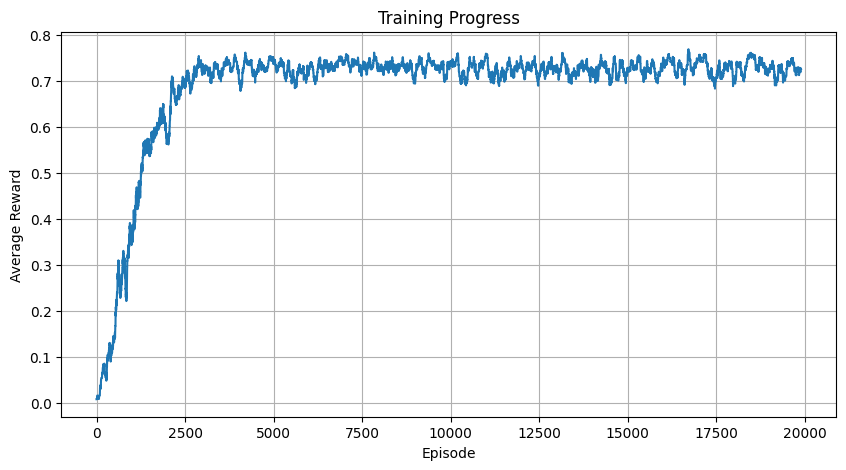

In [12]:
from utils import plot_rewards_curve
plot_rewards_curve(rewards_per_episode)

In [13]:
q_values

array([[0.33493908, 0.6867847 , 0.38338183, 0.33873722],
       [0.10651289, 0.        , 0.54323342, 0.11969483],
       [0.12460592, 0.65719863, 0.08515797, 0.15824225],
       [0.15028099, 0.        , 0.0707716 , 0.        ],
       [0.41276013, 0.74948069, 0.        , 0.40486287],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.81889715, 0.        , 0.35837554],
       [0.        , 0.        , 0.        , 0.        ],
       [0.52196657, 0.        , 0.81203087, 0.53615614],
       [0.6180643 , 0.74436963, 0.87688108, 0.        ],
       [0.72470632, 0.94387998, 0.        , 0.71656595],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.62586979, 0.92071202, 0.35873105],
       [0.80613851, 0.92541472, 1.        , 0.82349261],
       [0.        , 0.        , 0.        , 0.        ]])

In [14]:
env = gym.make("FrozenLake-v1", render_mode="human", is_slippery=False)
state, _ = env.reset()
gain = 0
import time
while True:
    action = q_values[state].argmax()
    state, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated
    env.render()
    time.sleep(1)
    gain += reward
    if done:
        break
print("total return: ", gain)

total return:  1


In [15]:
q_values

array([[0.33493908, 0.6867847 , 0.38338183, 0.33873722],
       [0.10651289, 0.        , 0.54323342, 0.11969483],
       [0.12460592, 0.65719863, 0.08515797, 0.15824225],
       [0.15028099, 0.        , 0.0707716 , 0.        ],
       [0.41276013, 0.74948069, 0.        , 0.40486287],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.81889715, 0.        , 0.35837554],
       [0.        , 0.        , 0.        , 0.        ],
       [0.52196657, 0.        , 0.81203087, 0.53615614],
       [0.6180643 , 0.74436963, 0.87688108, 0.        ],
       [0.72470632, 0.94387998, 0.        , 0.71656595],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.62586979, 0.92071202, 0.35873105],
       [0.80613851, 0.92541472, 1.        , 0.82349261],
       [0.        , 0.        , 0.        , 0.        ]])

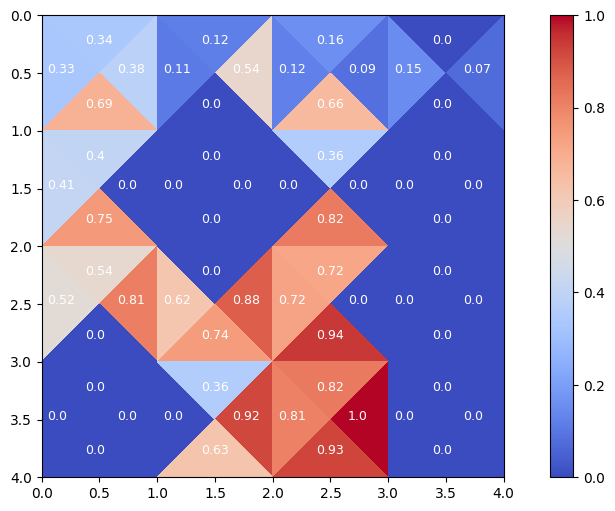

In [16]:
# 可视化动作价值
from utils import plot_action_value
plot_action_value(q_values)

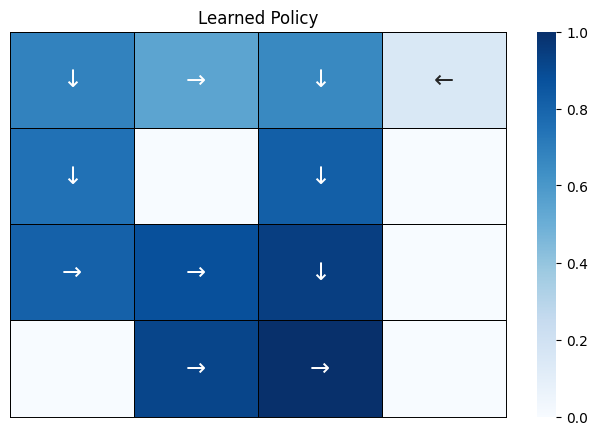

In [17]:
# 可视化动作策略
from utils import plot_policy_map
env = gym.make("FrozenLake-v1", render_mode="rgb_array", is_slippery=False)
env.reset()
plot_policy_map(q_values, env)